In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

In [2]:
DATA_ROOT = Path("../data/ddd")

classes = [d.name for d in sorted(DATA_ROOT.iterdir()) if d.is_dir()]
print("Classes:", classes)

counts = {}
for cls in classes:
    imgs = list((DATA_ROOT / cls).glob("*.jpg")) + \
           list((DATA_ROOT / cls).glob("*.png")) + \
           list((DATA_ROOT / cls).glob("*.jpeg"))
    counts[cls] = len(imgs)
    print(f"  {cls}: {len(imgs)} images")

print(f"\nTotal: {sum(counts.values())} images")

Classes: ['drowsy', 'non_drowsy']
  drowsy: 22348 images
  non_drowsy: 19445 images

Total: 41793 images


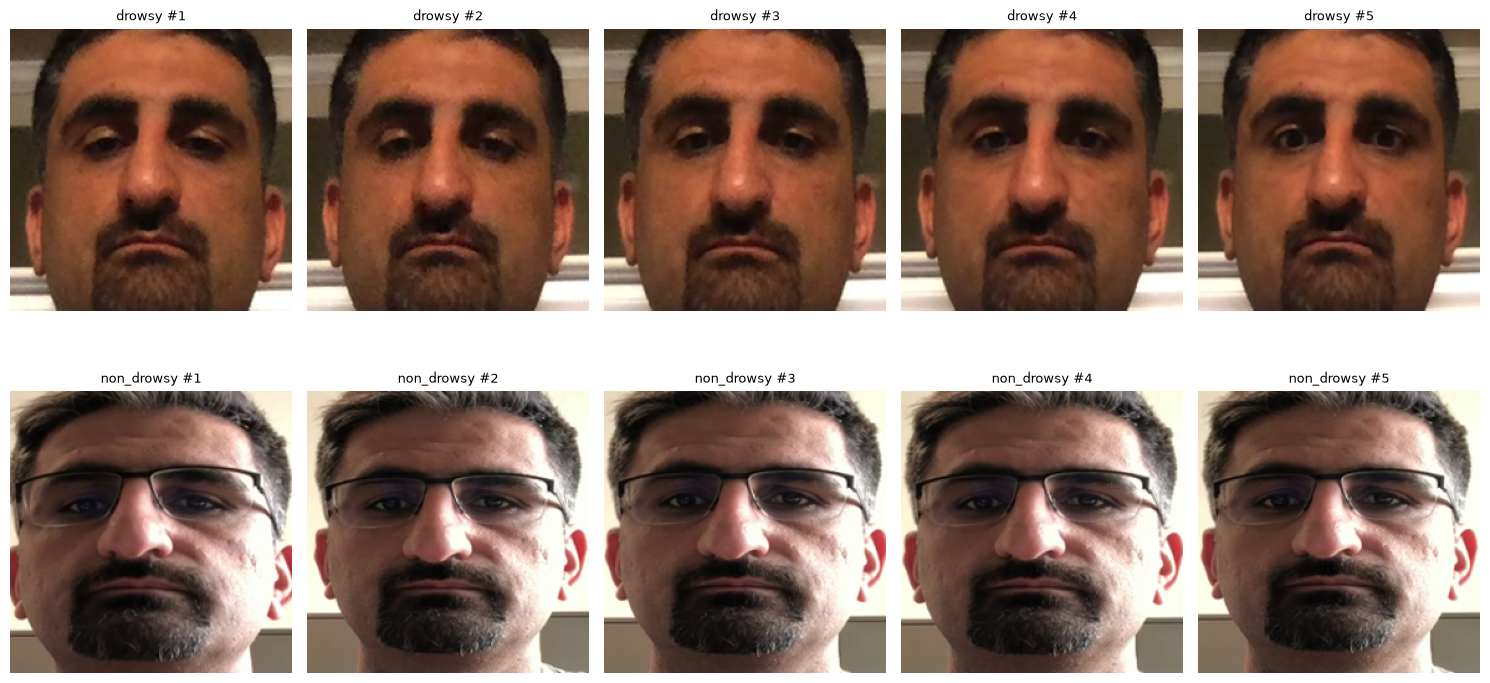

Saved to data/sample_grid.png


In [3]:
fig, axes = plt.subplots(len(classes), 5, figsize=(15, 4 * len(classes)))

for i, cls in enumerate(classes):
    imgs = list((DATA_ROOT / cls).glob("*.jpg")) + \
           list((DATA_ROOT / cls).glob("*.png")) + \
           list((DATA_ROOT / cls).glob("*.jpeg"))
    for j in range(5):
        img = cv2.imread(str(imgs[j]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i][j].imshow(img)
        axes[i][j].set_title(f"{cls} #{j+1}", fontsize=9)
        axes[i][j].axis("off")

plt.tight_layout()
plt.savefig("../data/sample_grid.png", dpi=100)
plt.show()
print("Saved to data/sample_grid.png")

In [4]:
for cls in classes:
    imgs = list((DATA_ROOT / cls).glob("*.jpg"))[:10]
    shapes = set()
    for p in imgs:
        img = cv2.imread(str(p))
        if img is not None:
            shapes.add(img.shape[:2])  # (H, W)
    print(f"{cls}: unique sizes = {shapes}")

drowsy: unique sizes = set()
non_drowsy: unique sizes = set()


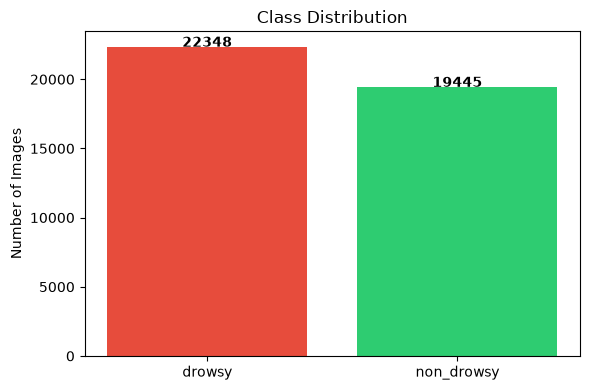

In [5]:
plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=["#e74c3c", "#2ecc71"])
plt.title("Class Distribution")
plt.ylabel("Number of Images")
for k, v in counts.items():
    plt.text(k, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("../data/class_distribution.png", dpi=100)
plt.show()